In [93]:
# Time to plot.
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # Use LaTeX for all text rendering
    "text.usetex": False,

    # Match LaTeX default font
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],

    # Font sizes (11pt article standard)
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Figure layout
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.autolayout": False,

    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 5,

    # Axes styling
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

FIGSIZE_SINGLE = (3.4, 2.5)   # inches
FIGSIZE_DOUBLE = (6.8, 3.5)
FIGSIZE_MEDIUM = (1.3 * FIGSIZE_SINGLE[0], 1.3 * FIGSIZE_SINGLE[1])
FIGSIZE_SINGLE_SQUARE = (3.4, 3.4)
FIGSIZE_MEDIUM_SQUARE = (3.4 * 1.3, 3.4 * 1.3)
FIGSIZE_PP = (6.8, 6.8/2.3567)

from cycler import cycler
cmap = plt.get_cmap("tab10")
colors = cmap(np.linspace(0, 1, 10))

mpl.rcParams['axes.prop_cycle'] = cycler(color=colors)
COL = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Illustrate data augmentation

In [5]:
import torch
from torchvision import datasets, transforms
from PIL import Image

In [2]:
def transform(image, horizontal_flip, color_jitter, rotation):
    image_size=224
    train_transform = transforms.Compose([
            transforms.RandomCrop(image_size),
            # transforms.RandomResizedCrop(
            #     image_size,
            #     scale=(0.7, 1.0),
            #     ratio=(0.75, 1.33)
            # ) if random_crop else None,#transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip() if horizontal_flip else None,
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            ) if color_jitter else None,
            transforms.RandomRotation(5) if rotation else None])
    return train_transform(image)

In [6]:
for i in range(5):
    img = Image.open("albania_image_downscaled.jpg")
    augmented_img = transform(img, horizontal_flip=True, color_jitter=True, rotation=True)
    augmented_img.save(f"augmented_example_images/albania_augmented_{i}.jpg")

## Test for duplicates

In [7]:
import hashlib
import os

In [ ]:
def find_and_delete_duplicates(directory, extensions=None, delete=False):
    if extensions is None:
        extensions = [".jpg", ".jpeg", ".png"]

    def file_hash(filepath):
        hasher = hashlib.md5()
        with open(filepath, "rb") as f:
            for chunk in iter(lambda: f.read(4096), b""):
                hasher.update(chunk)
        return hasher.hexdigest()

    hashes = {}
    duplicates = []

    for root, _, files in os.walk(directory):
        files.sort()
        for file in files:
            if any(file.lower().endswith(ext) for ext in extensions):
                filepath = os.path.join(root, file)
                try:
                    hash_value = file_hash(filepath)
                    if hash_value in hashes:
                        duplicates.append(filepath)
                        
                        if delete:
                            os.remove(filepath)
                            print(f"Deleted duplicate: {filepath}")
                        else:
                            print(f"Found duplicate: {filepath}")
                            #print(hash_value)
                            #print(hashes[hash_value])
                    else:
                        hashes[hash_value] = filepath
                except Exception as e:
                    print(f"Error processing file {filepath}: {e}")

    return duplicates

In [22]:
dir = "/Users/august/Desktop/AppliedMLdata2026"
d = find_and_delete_duplicates(dir, delete=False)

In [21]:
print(len(d))

348


In [25]:
# Print all folder names in directory
dir = "/Users/august/Desktop/AppliedMLdata2026/train_data"
countries = []
for root, dirs, files in os.walk(dir):
    for d in dirs:
        countries.append(d)

# sort alphabetically
countries.sort()
print(countries)

['Albania', 'Argentina', 'Australia', 'Austria', 'Bangladesh', 'Belgium', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Cambodia', 'Canada', 'Chile', 'Colombia', 'Croatia', 'Denmark', 'DominicanRepublic', 'Ecuador', 'Estonia', 'Eswatini', 'Finland', 'France', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malaysia', 'Malta', 'Mexico', 'Mongolia', 'Montenegro', 'Netherlands', 'NewZealand', 'Nigeria', 'NorthMacedonia', 'Norway', 'Oman', 'Panama', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russia', 'Rwanda', 'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'SouthAfrica', 'SouthKorea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Tunisia', 'Turkey', 'USA', 'Uganda', 'Ukraine', 'UnitedArabEmirates', 'UnitedKingdom', 'Uruguay']


In [41]:
import pandas as pd
# select column 1
class_names = pd.read_csv("../country_to_idx.csv", header=None).iloc[:, 0].tolist()

print(class_names)

['Albania', 'Argentina', 'Australia', 'Austria', 'Bangladesh', 'Belgium', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Cambodia', 'Canada', 'Chile', 'Colombia', 'Croatia', 'Denmark', 'DominicanRepublic', 'Ecuador', 'Estonia', 'Eswatini', 'Finland', 'France', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malaysia', 'Malta', 'Mexico', 'Mongolia', 'Montenegro', 'Netherlands', 'NewZealand', 'Nigeria', 'NorthMacedonia', 'Norway', 'Oman', 'Panama', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russia', 'Rwanda', 'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'SouthAfrica', 'SouthKorea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Tunisia', 'Turkey', 'USA', 'Uganda', 'Ukraine', 'UnitedArabEmirates', 'UnitedKingdom', 'Uruguay']


# Vis overtraining

In [4]:
import pandas as pd
history_50 = pd.read_csv("resnet50_classification_history.csv")
history_34 = pd.read_csv("resnet34_classification_history.csv")
history_18 = pd.read_csv("resnet18_classification_history.csv")

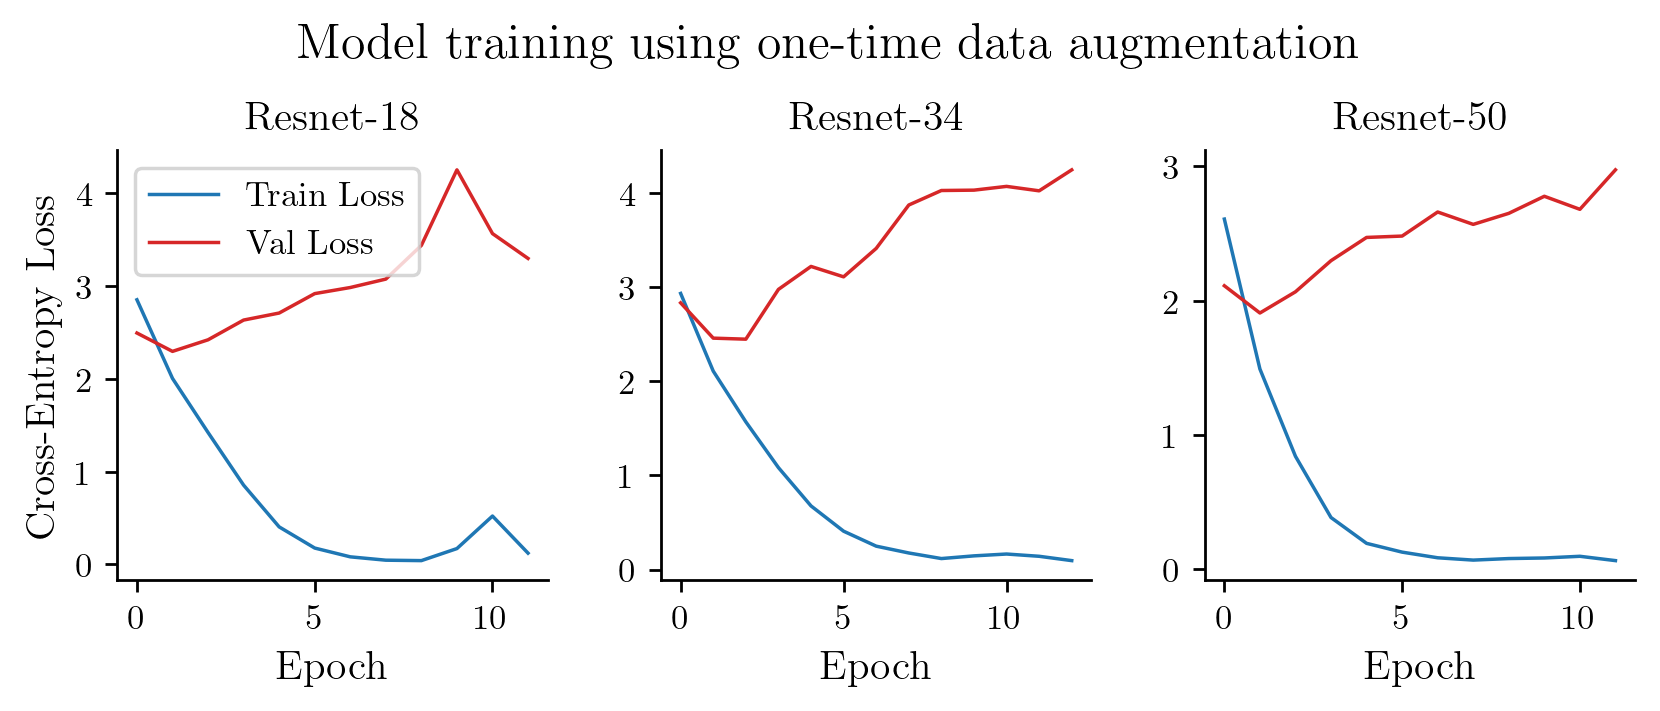

In [45]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,3,figsize=(FIGSIZE_PP))
ax = ax.flatten()
c1 = COL[0]
c2 = COL[3]
lw = 1

ax[2].plot(history_50["train_loss"], label="Train Loss", color=c1, linewidth=lw)
ax[1].plot(history_34["train_loss"], label="Train Loss", color=c1, linewidth=lw)
ax[0].plot(history_18["train_loss"], label="Train Loss", color=c1, linewidth=lw)

ax[2].plot(history_50["val_loss"], label="Val Loss", color=c2, linewidth=lw)
ax[1].plot(history_34["val_loss"], label="Val Loss", color=c2, linewidth=lw)
ax[0].plot(history_18["val_loss"], label="Val Loss", color=c2, linewidth=lw)

ax[2].set_title("Resnet-50")
ax[1].set_title("Resnet-34")
ax[0].set_title("Resnet-18")
ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[2].set_xlabel("Epoch")
ax[0].set_ylabel("Cross-Entropy Loss")

ax[0].legend(loc="upper left") 
plt.suptitle("Model training using one-time data augmentation")
plt.tight_layout(rect=[0, 0, 1, 1.06])
plt.savefig("training_history_plot.png", dpi=300)

In [53]:
import sys
sys.path.append("..")
from src.model import make_model

In [54]:
model = make_model("resnet18")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/august/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 14.4MB/s]


In [55]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# per country performance

In [62]:
report = pd.read_csv("resnet50_test_classification_report.csv")
print(report.to_string())

            Unnamed: 0  precision    recall  f1-score      support
0              Albania   0.714286  0.666667  0.689655    60.000000
1            Argentina   0.337500  0.457627  0.388489    59.000000
2            Australia   0.674419  0.483333  0.563107    60.000000
3              Austria   0.400000  0.366667  0.382609    60.000000
4           Bangladesh   0.914286  0.542373  0.680851    59.000000
5              Belgium   0.326087  0.250000  0.283019    60.000000
6               Bhutan   0.816667  0.816667  0.816667    60.000000
7              Bolivia   0.634615  0.550000  0.589286    60.000000
8             Botswana   0.763636  0.700000  0.730435    60.000000
9               Brazil   0.297619  0.416667  0.347222    60.000000
10            Bulgaria   0.477612  0.533333  0.503937    60.000000
11            Cambodia   0.552632  0.350000  0.428571    60.000000
12              Canada   0.652174  0.250000  0.361446    60.000000
13               Chile   0.509091  0.466667  0.486957    60.00

In [65]:
print(report.sort_values(by="precision", ascending=False).to_string())

            Unnamed: 0  precision    recall  f1-score      support
28             Iceland   1.000000  0.333333  0.500000    60.000000
65              Rwanda   0.957447  0.750000  0.841121    60.000000
62               Qatar   0.946429  0.883333  0.913793    60.000000
4           Bangladesh   0.914286  0.542373  0.680851    59.000000
24               Ghana   0.895833  0.716667  0.796296    60.000000
49            Mongolia   0.884615  0.766667  0.821429    60.000000
34               Japan   0.864865  0.533333  0.659794    60.000000
80              Uganda   0.860000  0.716667  0.781818    60.000000
29               India   0.860000  0.716667  0.781818    60.000000
66             Senegal   0.857143  0.900000  0.878049    60.000000
41             Lebanon   0.840580  0.966667  0.899225    60.000000
53             Nigeria   0.833333  0.583333  0.686275    60.000000
82  UnitedArabEmirates   0.829787  0.650000  0.728972    60.000000
6               Bhutan   0.816667  0.816667  0.816667    60.00

In [68]:
class_names = ['Albania', 'Argentina', 'Australia', 'Austria', 'Bangladesh', 'Belgium', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Cambodia', 'Canada', 'Chile', 'Colombia', 'Croatia', 'Denmark', 'DominicanRepublic', 'Ecuador', 'Estonia', 'Eswatini', 'Finland', 'France', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malaysia', 'Malta', 'Mexico', 'Mongolia', 'Montenegro', 'Netherlands', 'NewZealand', 'Nigeria', 'NorthMacedonia', 'Norway', 'Oman', 'Panama', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russia', 'Rwanda', 'Senegal', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'SouthAfrica', 'SouthKorea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Tunisia', 'Turkey', 'USA', 'Uganda', 'Ukraine', 'UnitedArabEmirates', 'UnitedKingdom', 'Uruguay']
european_countries = ['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia',
        'Denmark', 'Estonia', 'Finland', 'France', 'Germany',
        'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy',
        'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
        'Montenegro', 'Netherlands', 'NorthMacedonia',
        'Norway', 'Poland', 'Portugal', 'Romania',
        'Russia', 'Serbia', 'Slovakia', 'Slovenia',
        'Spain', 'Sweden', 'Switzerland', 'Ukraine',
        'UnitedKingdom']
print(len(european_countries))
print(19/25)
print(35/85)

35
0.76
0.4117647058823529


In [81]:
# Change a few country names to abbreviations
# UnitedArabEmirates -> UAE
# UnitedKingdom -> UK

# Change column "Unnamed: 0" to "country"
report = report.rename(columns={"Unnamed: 0": "country"})

report["country"] = report["country"].replace({
    "UnitedArabEmirates": "UAE",
    "UnitedKingdom": "UK"
})

In [82]:
top = report.sort_values(by="precision", ascending=False).to_string()
bottom = report.sort_values(by="precision", ascending=True).to_string()

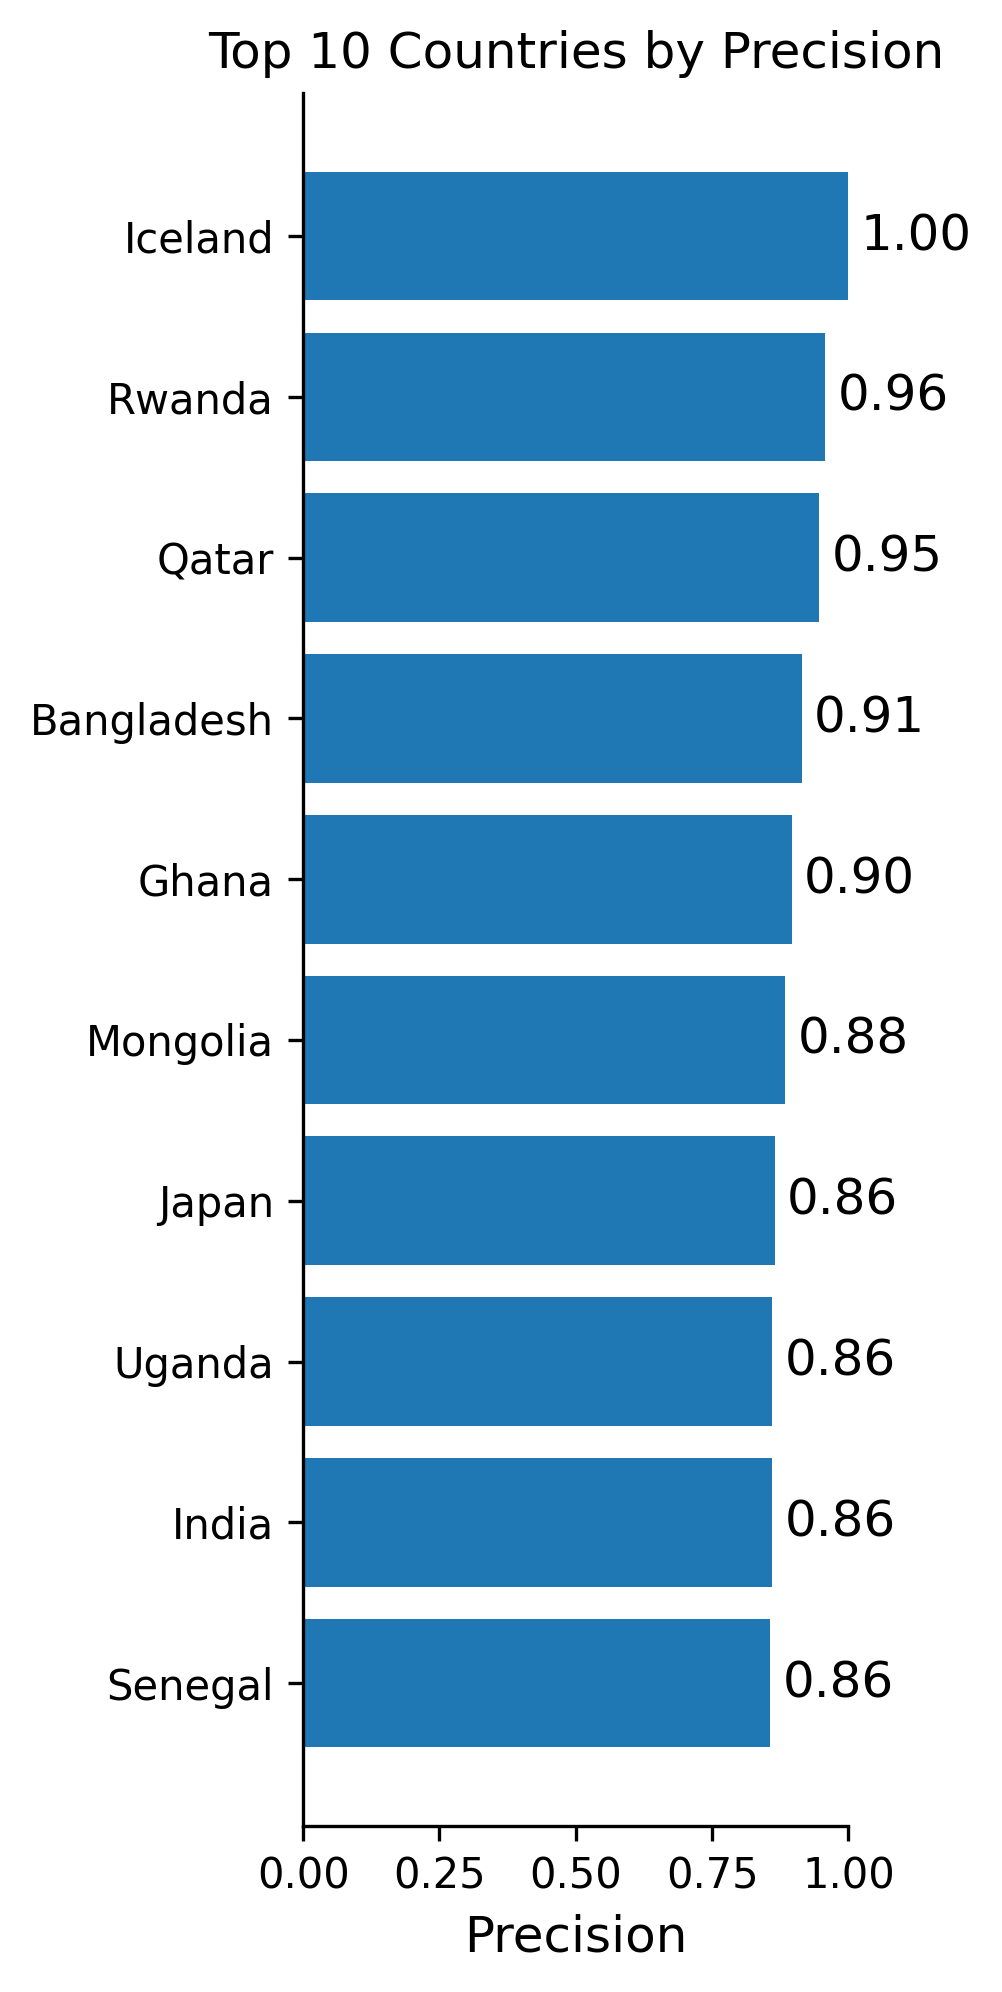

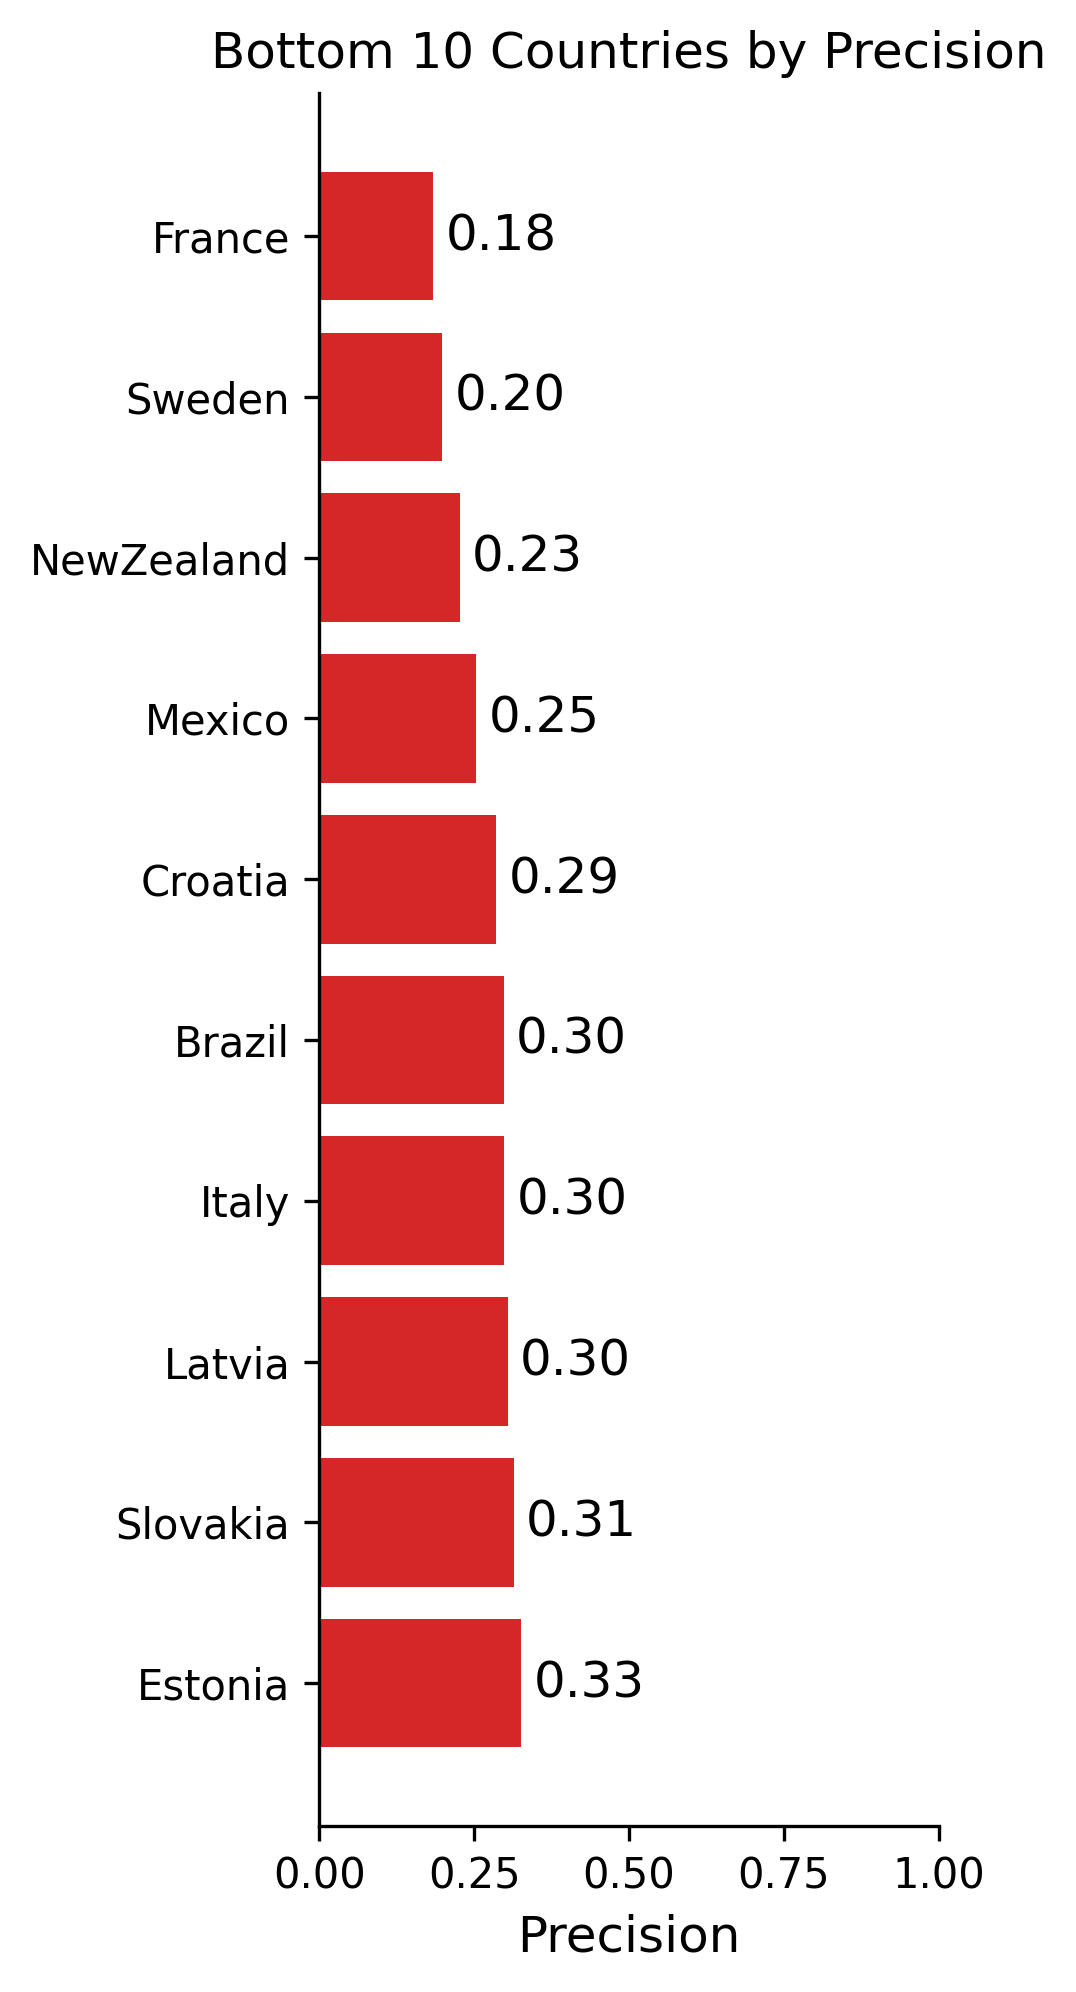

In [97]:
k = 10

# Plot sideways histogram
top_plot = report.sort_values(by="precision", ascending=False).head(k)
bottom_plot = report.sort_values(by="precision", ascending=True).head(k)
# invert the lists
top_plot = top_plot.iloc[::-1]
bottom_plot = bottom_plot.iloc[::-1]

# Top precision plot
fig, ax = plt.subplots(figsize=(3.5,6.8))
bars1 = ax.barh(top_plot["country"], top_plot["precision"], color=COL[0])
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.set_title(f"Top {k} Countries by Precision")
ax.set_xlabel("Precision")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("precision_histogram_top.png", dpi=300)
plt.show()

# Bottom precision plot
fig, ax = plt.subplots(figsize=(3.5,6.8))
bars2 = ax.barh(bottom_plot["country"], bottom_plot["precision"], color=COL[3])
ax.bar_label(bars2, fmt='%.2f', padding=3)
ax.set_title(f"Bottom {k} Countries by Precision")
ax.set_xlabel("Precision")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("precision_histogram_bottom.png", dpi=300)
plt.show()

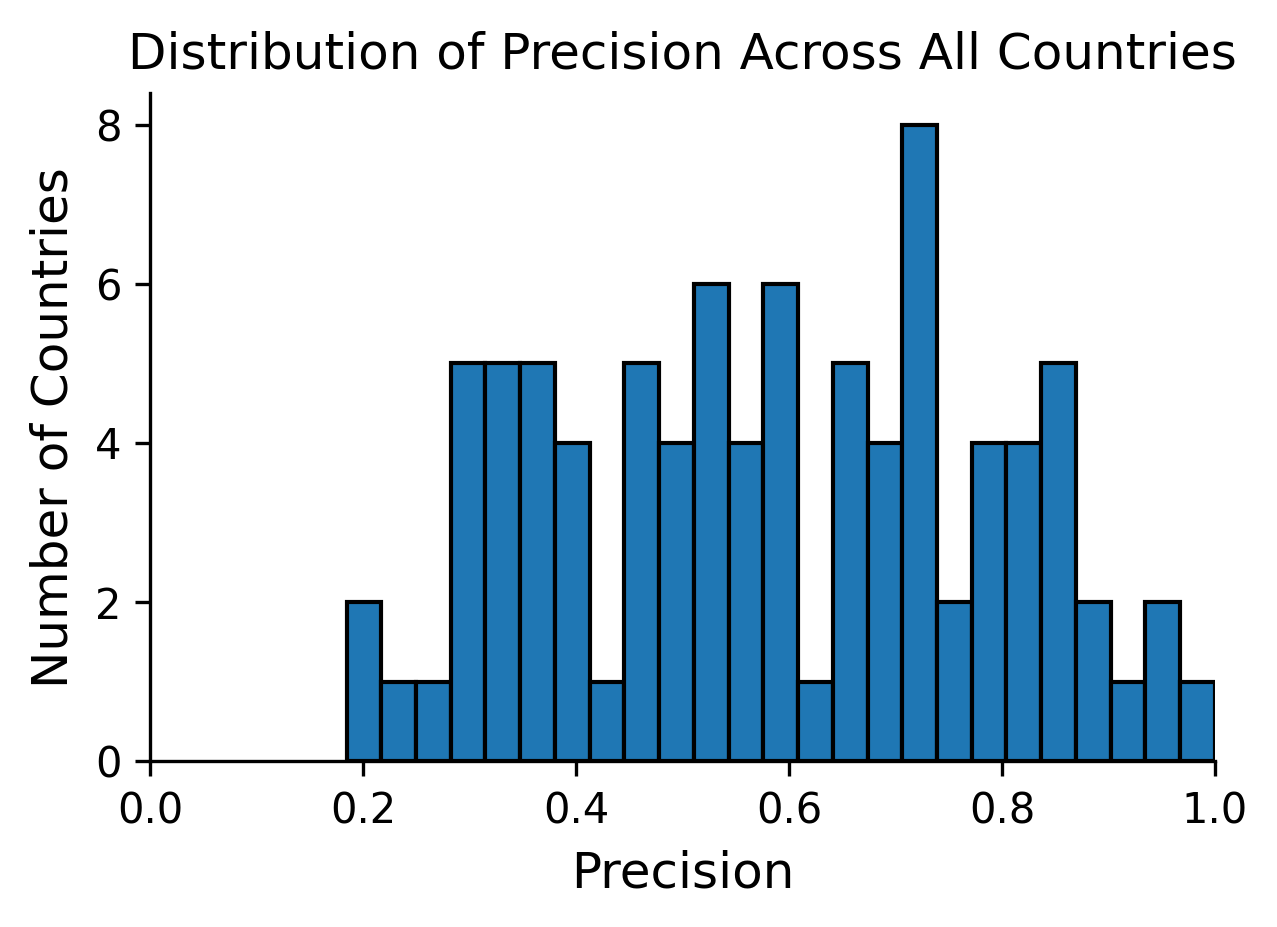

In [107]:
# Plot histogram of precision distribution
fig, ax = plt.subplots(figsize=(FIGSIZE_MEDIUM))
ax.hist(report["precision"], bins=25, color=COL[0], edgecolor='black')
ax.set_title("Distribution of Precision Across All Countries")
ax.set_xlabel("Precision")
ax.set_ylabel("Number of Countries")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("precision_distribution.png", dpi=300)
plt.show()